# Public Debt Dynamics in The Gambia: Time-Series Analysis and Visualization, 2000–2025

1. Project Overview

This notebook analyzes the evolution of public debt and selected fiscal and macroeconomic indicators in The Gambia from 2000 to 2025.

The purpose of the notebook is to clean, transform, explore, and visualize annual macroeconomic and fiscal data before conducting econometric analysis in Stata.

The analysis focuses particularly on:

* Public debt
* Debt-to-GDP ratio
* Fiscal balance
* Primary balance
* Government revenue
* Government expenditure
* GDP growth
* Inflation
* Current account balance
* Annual changes in the debt-to-GDP ratio
* Exchange rates gmd per dollar


2. Research Objective

The main objective is to understand how public debt in The Gambia has evolved over time and to identify important patterns between debt dynamics and selected fiscal and macroeconomic indicators.

The notebook focuses on descriptive and exploratory analysis rather than making causal claims.


3. Data Sources

The main data used in this notebook are obtained from international macroeconomic databases, particularly the International Monetary Fund (IMF) World Economic Outlook database.

Additional external public debt information may be obtained from the World Bank.

The analysis covers the period:

2000–2025

The data are annual observations.

# Python Libraries

The following Python libraries are used for data manipulation, numerical analysis, and visualization.

In [254]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from imf_reader import weo
import imf_reader
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
import statsmodels.formula.api as smf
import requests
import wbdata
sns.set_theme(style = "whitegrid", context ="notebook")

In [255]:
df = weo.fetch_data()
df.head()

INFO: Cache hit for WEO data: October 2025


,UNIT_CODE,CONCEPT_CODE,REF_AREA_CODE,FREQ_CODE,LASTACTUALDATE,SCALE_CODE,NOTES,TIME_PERIOD,OBS_VALUE,UNIT_LABEL,CONCEPT_LABEL,REF_AREA_LABEL,FREQ_LABEL,SCALE_LABEL
0,USD,BCA,ABW,A,<NA>,1000000000,<NA>,1999,-0.435363,US dollar,"Current account balance (credit less debit), U...","Aruba, Kingdom of the Netherlands",Annual,Billions
1,USD,BCA,ABW,A,<NA>,1000000000,<NA>,2000,0.212542,US dollar,"Current account balance (credit less debit), U...","Aruba, Kingdom of the Netherlands",Annual,Billions
2,USD,BCA,ABW,A,<NA>,1000000000,<NA>,2001,0.310076,US dollar,"Current account balance (credit less debit), U...","Aruba, Kingdom of the Netherlands",Annual,Billions
3,USD,BCA,ABW,A,<NA>,1000000000,<NA>,2002,-0.33344,US dollar,"Current account balance (credit less debit), U...","Aruba, Kingdom of the Netherlands",Annual,Billions
4,USD,BCA,ABW,A,<NA>,1000000000,<NA>,2003,-0.167256,US dollar,"Current account balance (credit less debit), U...","Aruba, Kingdom of the Netherlands",Annual,Billions


# IMPORT EXCHANGE RATE FROM WORLD BANK DATA

In [256]:
indicators = {"PA.NUS.FCRF": "Exchange_Rate_GMD_per_USD"}
country = "GMB"

# Get the dataframe from World Bank data
wb = wbdata.get_dataframe(indicators=indicators, country=country)

# wbdata returns data with 'date' as the index. Reset it to make 'date' a column:
wb = wb.reset_index()

# Convert the 'date' column (which contains year strings like '2020') to integers
wb["date"] = wb["date"].astype(int)

# Filter for the years 2000 to 2025
wb = wb[(wb["date"] >= 2000) & (wb["date"] <= 2025)]
wb

,date,Exchange_Rate_GMD_per_USD
0,2025,71.289382
1,2024,67.661238
2,2023,61.096333
3,2022,54.923467
4,2021,51.484444
5,2020,51.501660
6,2019,50.062461
7,2018,48.151781
8,2017,46.608909
9,2016,43.372528


In [257]:
wb["year"] = pd.to_datetime(wb["date"])

In [190]:
wb = wb.drop(columns = "date")

# FILTER DATA TO GAMBIA
The IMF data are imported and filtered to obtain observations for The Gambia.

The relevant fiscal and macroeconomic indicators are selected and reshaped into a country-year dataset.

The resulting dataset contains one observation for each year and separate columns for the main economic variables.

In [191]:
gambia =df[df["REF_AREA_CODE"] == "GMB"]
gambia.head(100)

,UNIT_CODE,CONCEPT_CODE,REF_AREA_CODE,FREQ_CODE,LASTACTUALDATE,SCALE_CODE,NOTES,TIME_PERIOD,OBS_VALUE,UNIT_LABEL,CONCEPT_LABEL,REF_AREA_LABEL,FREQ_LABEL,SCALE_LABEL
139204,USD,BCA,GMB,A,<NA>,1000000000,<NA>,1980,-0.117448,US dollar,"Current account balance (credit less debit), U...","Gambia, The",Annual,Billions
139205,USD,BCA,GMB,A,<NA>,1000000000,<NA>,1981,-0.034626,US dollar,"Current account balance (credit less debit), U...","Gambia, The",Annual,Billions
139206,USD,BCA,GMB,A,<NA>,1000000000,<NA>,1982,-0.006367,US dollar,"Current account balance (credit less debit), U...","Gambia, The",Annual,Billions
139207,USD,BCA,GMB,A,<NA>,1000000000,<NA>,1983,-0.003575,US dollar,"Current account balance (credit less debit), U...","Gambia, The",Annual,Billions
139208,USD,BCA,GMB,A,<NA>,1000000000,<NA>,1984,-0.013341,US dollar,"Current account balance (credit less debit), U...","Gambia, The",Annual,Billions
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139299,PT,BCA_NGDPD,GMB,A,<NA>,1,<NA>,2023,-5.427151,Percent,"Current account balance (credit less debit), P...","Gambia, The",Annual,Units
139300,PT,BCA_NGDPD,GMB,A,<NA>,1,<NA>,2024,-6.540692,Percent,"Current account balance (credit less debit), P...","Gambia, The",Annual,Units
139301,PT,BCA_NGDPD,GMB,A,<NA>,1,<NA>,2025,-4.946661,Percent,"Current account balance (credit less debit), P...","Gambia, The",Annual,Units
139302,PT,BCA_NGDPD,GMB,A,<NA>,1,<NA>,2026,-5.069135,Percent,"Current account balance (credit less debit), P...","Gambia, The",Annual,Units


In [192]:
gambia[["CONCEPT_CODE", "CONCEPT_LABEL"]].drop_duplicates()

,CONCEPT_CODE,CONCEPT_LABEL
139204,BCA,"Current account balance (credit less debit), U..."
139256,BCA_NGDPD,"Current account balance (credit less debit), P..."
139308,GGR,"Revenue, General government, Domestic currency"
139340,GGR_NGDP,"Revenue, General government, Percent of GDP"
139372,GGSB,"Structural balance, General government, Domest..."
139404,GGSB_NPGDP,"Structural balance, General government, Percent"
139436,GGX,"Expenditure, General government, Domestic curr..."
139468,GGXCNL,"Net lending (+) / net borrowing (-), General g..."
139500,GGXCNL_NGDP,"Net lending (+) / net borrowing (-), General g..."
139532,GGXONLB,"Primary net lending (+) / net borrowing (-), G..."


In [193]:
codes = ["GGXWDG","GGXWDG_NGDP", "GGR_NGDP", "GGX_NGDP","GGXCNL_NGDP", "GGXONLB_NGDP", "NGDP_RPCH","PCPIPCH", "BCA_NGDPD"]

In [194]:
dir(imf_reader)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'config',
 'utils',
 'version',
 'weo']

In [195]:
gambia_fiscal = gambia[gambia["CONCEPT_CODE"].isin(codes)][["TIME_PERIOD","CONCEPT_CODE","OBS_VALUE"]].copy()

In [196]:
gambia_fiscal.head(10)

,TIME_PERIOD,CONCEPT_CODE,OBS_VALUE
139256,1980,BCA_NGDPD,-19.388419
139257,1981,BCA_NGDPD,-5.970773
139258,1982,BCA_NGDPD,-1.164494
139259,1983,BCA_NGDPD,-0.649443
139260,1984,BCA_NGDPD,-3.367032
139261,1985,BCA_NGDPD,-1.296517
139262,1986,BCA_NGDPD,-0.383042
139263,1987,BCA_NGDPD,-0.838561
139264,1988,BCA_NGDPD,1.636086
139265,1989,BCA_NGDPD,0.843665


In [197]:
gambia_fiscal = gambia_fiscal[gambia_fiscal["TIME_PERIOD"].between(2000,2025)].copy()

In [198]:
gambia_fiscal["TIME_PERIOD"].min(), gambia_fiscal["TIME_PERIOD"].max()

(np.int64(2000), np.int64(2025))

# CHANGE DATA FROM WIDE FORMAT TO LONG FORMAT

In [199]:
gambia_fiscal = gambia_fiscal.pivot(index = "TIME_PERIOD",
                                    columns = "CONCEPT_CODE",
                                    values = "OBS_VALUE").reset_index()

In [200]:
gambia[gambia["CONCEPT_CODE"]== "GGXWDG_NGDP"][["CONCEPT_CODE","OBS_VALUE","SCALE_LABEL"]].drop_duplicates()

,CONCEPT_CODE,OBS_VALUE,SCALE_LABEL
139628,GGXWDG_NGDP,73.250229,Units
139629,GGXWDG_NGDP,75.229867,Units
139630,GGXWDG_NGDP,93.875279,Units
139631,GGXWDG_NGDP,91.694292,Units
139632,GGXWDG_NGDP,81.303059,Units
139633,GGXWDG_NGDP,82.596471,Units
139634,GGXWDG_NGDP,87.344267,Units
139635,GGXWDG_NGDP,38.022861,Units
139636,GGXWDG_NGDP,39.528277,Units
139637,GGXWDG_NGDP,38.868143,Units


In [201]:
gambia_fiscal

CONCEPT_CODE,TIME_PERIOD,BCA_NGDPD,GGR_NGDP,GGXCNL_NGDP,GGXONLB_NGDP,GGXWDG,GGXWDG_NGDP,GGX_NGDP,NGDP_RPCH,PCPIPCH
0,2000,-3.434987,9.447169,-0.090777,1.82446,9.457098,73.250229,9.537946,5.524896,0.850872
1,2001,-3.296738,7.158574,-2.522861,-0.65482,11.830455,75.229867,9.681435,5.753038,4.492237
2,2002,-3.683212,8.653991,0.059383,2.157048,16.58288,93.875279,8.594608,-3.246948,8.6097
3,2003,-4.625704,7.569832,-1.732202,0.794467,22.050158,91.694292,9.302034,6.874318,17.031669
4,2004,-2.72021,10.610562,-1.766022,1.238653,23.485166,81.303059,12.376584,7.045586,14.287287
5,2005,-6.283065,9.614405,-3.332376,0.518411,24.256108,82.596471,12.946781,-2.351729,4.959359
6,2006,-4.296032,10.827504,-3.193722,-0.079113,25.840305,87.344267,14.021226,-0.555581,2.055788
7,2007,-5.179509,11.469229,0.274808,2.835338,12.102908,38.022861,11.194421,3.043249,5.36971
8,2008,-7.562541,11.096676,-0.454399,0.956524,13.700216,39.528277,11.551075,6.255906,4.451085
9,2009,-7.782691,12.705557,-1.647544,0.271337,15.01792,38.868143,14.353101,6.665724,4.554231


RENAME COLUMNS TO SIMPLER VERSIONS

In [202]:
gambia_fiscal = gambia_fiscal.rename(columns={

    "TIME_PERIOD": "year",

    "GGXWDG": "total_debt",

    "GGXWDG_NGDP": "debt_gdp",

    "GGR_NGDP": "revenue_gdp",

    "GGX_NGDP": "expenditure_gdp",

    "GGXCNL_NGDP": "fiscal_balance_gdp",

    "GGXONLB_NGDP": "primary_balance_gdp",

    "NGDP_RPCH": "gdp_growth",

    "PCPIPCH": "inflation",

    "BCA_NGDPD": "current_account_gdp"})

In [203]:
gambia_fiscal

CONCEPT_CODE,year,current_account_gdp,revenue_gdp,fiscal_balance_gdp,primary_balance_gdp,total_debt,debt_gdp,expenditure_gdp,gdp_growth,inflation
0,2000,-3.434987,9.447169,-0.090777,1.82446,9.457098,73.250229,9.537946,5.524896,0.850872
1,2001,-3.296738,7.158574,-2.522861,-0.65482,11.830455,75.229867,9.681435,5.753038,4.492237
2,2002,-3.683212,8.653991,0.059383,2.157048,16.58288,93.875279,8.594608,-3.246948,8.6097
3,2003,-4.625704,7.569832,-1.732202,0.794467,22.050158,91.694292,9.302034,6.874318,17.031669
4,2004,-2.72021,10.610562,-1.766022,1.238653,23.485166,81.303059,12.376584,7.045586,14.287287
5,2005,-6.283065,9.614405,-3.332376,0.518411,24.256108,82.596471,12.946781,-2.351729,4.959359
6,2006,-4.296032,10.827504,-3.193722,-0.079113,25.840305,87.344267,14.021226,-0.555581,2.055788
7,2007,-5.179509,11.469229,0.274808,2.835338,12.102908,38.022861,11.194421,3.043249,5.36971
8,2008,-7.562541,11.096676,-0.454399,0.956524,13.700216,39.528277,11.551075,6.255906,4.451085
9,2009,-7.782691,12.705557,-1.647544,0.271337,15.01792,38.868143,14.353101,6.665724,4.554231


# EXPLORE DATASETS

In [204]:
gambia_fiscal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 26 non-null     Int64  
 1   current_account_gdp  26 non-null     Float64
 2   revenue_gdp          26 non-null     Float64
 3   fiscal_balance_gdp   26 non-null     Float64
 4   primary_balance_gdp  26 non-null     Float64
 5   total_debt           26 non-null     Float64
 6   debt_gdp             26 non-null     Float64
 7   expenditure_gdp      26 non-null     Float64
 8   gdp_growth           26 non-null     Float64
 9   inflation            26 non-null     Float64
dtypes: Float64(9), Int64(1)
memory usage: 2.4 KB


# Descriptive statistics

In [205]:
gambia_fiscal.describe()

CONCEPT_CODE,year,current_account_gdp,revenue_gdp,fiscal_balance_gdp,primary_balance_gdp,total_debt,debt_gdp,expenditure_gdp,gdp_growth,inflation
count,26.0,26.0,26.0,26.0,26.0,26.0,26.0,26.0,26.0,26.0
mean,2012.5,-6.082298,14.42767,-3.008838,-0.149669,47.83384,71.454771,17.436508,3.561044,7.291252
std,7.648529,2.115823,4.890277,1.751462,1.403645,38.874125,17.601975,5.806232,3.864341,4.018826
min,2000.0,-10.048784,7.158574,-6.22401,-3.555196,9.457098,38.022861,8.594608,-8.130444,0.850872
25%,2006.25,-7.421219,10.894797,-3.987532,-0.891816,19.037874,61.025349,12.519133,2.175712,4.837006
50%,2012.5,-5.967657,13.332411,-2.988284,-0.12797,27.324984,77.92083,18.080785,5.374484,6.391649
75%,2018.75,-4.341446,18.371886,-1.916732,0.725453,73.308878,83.475031,23.090568,5.982458,8.000288
max,2025.0,-2.72021,24.189037,0.274808,2.835338,137.041926,93.875279,27.137719,7.23489,17.031669


A HEAT MAP TO EXAMINE THE VARIABLES RELATIONSHIPS

# A HEAT MAP
A correlation matrix is used to examine the linear relationships among selected fiscal and macroeconomic variables.

The correlation analysis provides an initial understanding of the relationships in the dataset and can also help identify potentially highly correlated explanatory variables before econometric modelling.

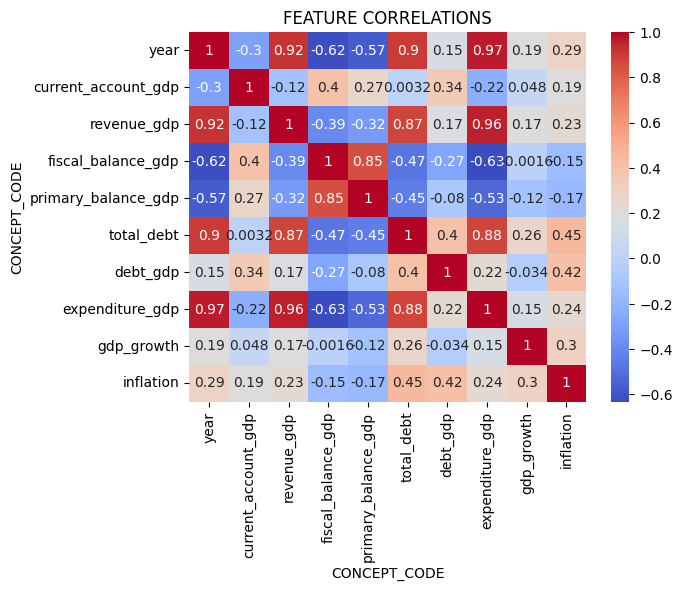

In [206]:
corr = gambia_fiscal.corr(numeric_only=True)
sns.heatmap(corr,
            annot = True,
            cmap = "coolwarm")
plt.title("FEATURE CORRELATIONS")
plt.show()

# TREND ANALYSIS

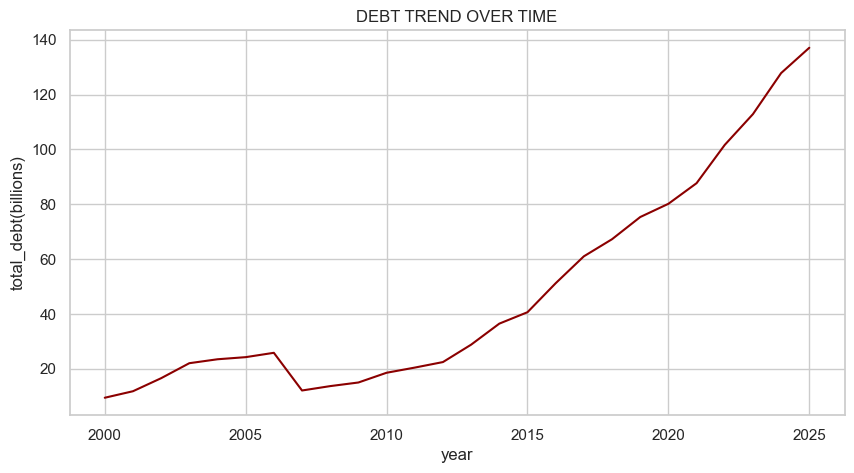

In [280]:
plt.figure(figsize=(10,5))
sns.lineplot(data = gambia_fiscal,
             x = "year",
             y = "total_debt",
             errorbar=None,
             color = "darkred")
plt.title("DEBT TREND OVER TIME")
plt.ylabel("total_debt(billions)")
plt.savefig("total_debt_trend_over_time", dpi = 300, bbox_inches = "tight")
plt.show()

# Public Debt-to-GDP Ratio

The first major visualization examines the evolution of the public debt-to-GDP ratio between 2000 and 2025.

The debt-to-GDP ratio is an important indicator of the size of government debt relative to the country’s economic output.

This visualization helps identify periods in which the debt burden increased or declined substantially.

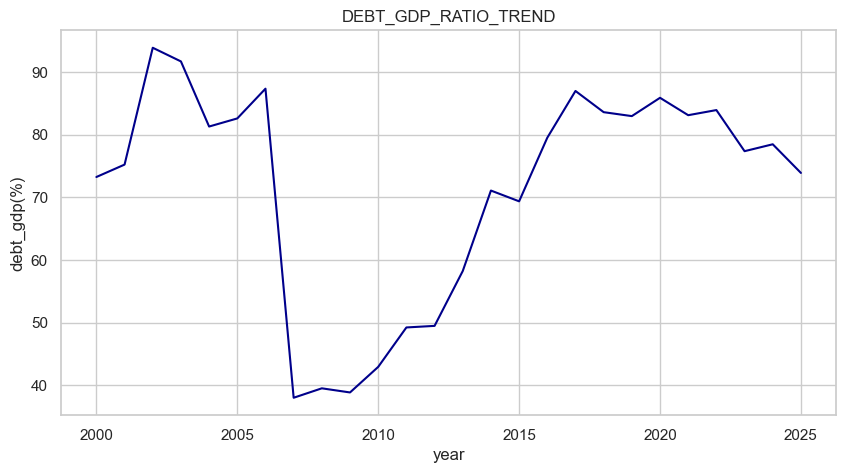

In [279]:
plt.figure(figsize=(10,5))
sns.lineplot(data = gambia_fiscal,
             x = "year",
             y = "debt_gdp",
             errorbar=None,
             color = "darkblue")
plt.title("DEBT_GDP_RATIO_TREND")
plt.savefig("debt_gdp_trend", dpi = 300, bbox_inches = "tight")
plt.ylabel("debt_gdp(%)")
plt.show()

 # DEBT_GDP VS GDP_GROWTH
A scatter plot i created to see the relationship between debt_gdp and gdp_growth over the period.

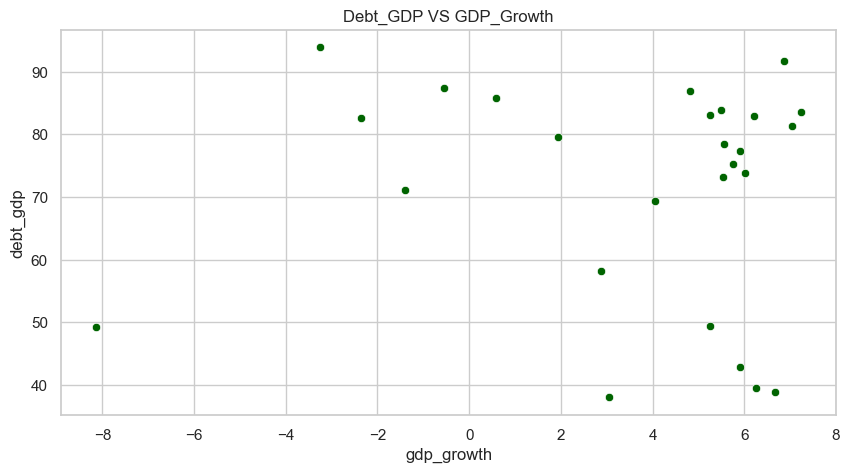

In [278]:
plt.figure(figsize=(10,5))
sns.scatterplot(data = gambia_fiscal,
                x = "gdp_growth",
                y = "debt_gdp",
                color = "darkgreen")
plt.title("Debt_GDP VS GDP_Growth")
plt.savefig("debt_gdp_vs_gdp_growth", dpi = 300, bbox_inches = "tight")
plt.show()

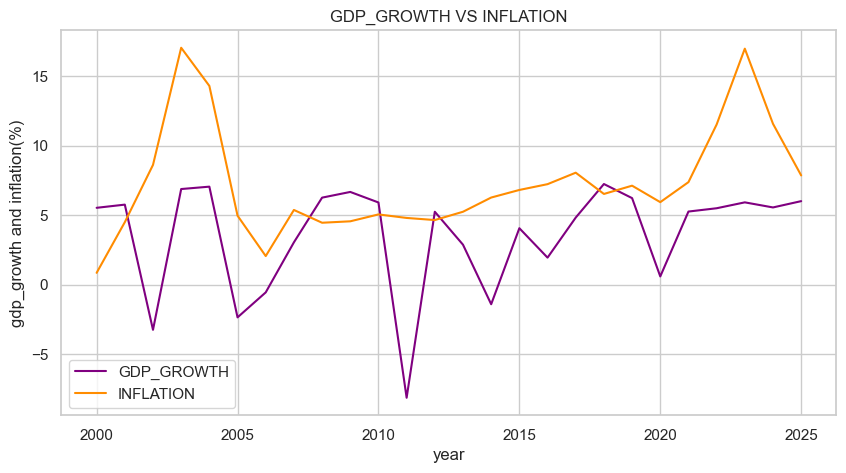

In [275]:
plt.figure(figsize=(10,5))
sns.lineplot(data = gambia_fiscal,
             x = "year",
             y = "gdp_growth",
             errorbar=None,
             color = "purple",
            label = "GDP_GROWTH")
sns.lineplot(data = gambia_fiscal,
             x = "year",
             y = "inflation",
             errorbar=None,
             color = "darkorange",
             label = "INFLATION")
plt.title("GDP_GROWTH VS INFLATION")
plt.ylabel("gdp_growth and inflation(%)")
plt.savefig("gdp_growth vs inflation", dpi = 300, bbox_inches = "tight")
plt.legend()
plt.show()

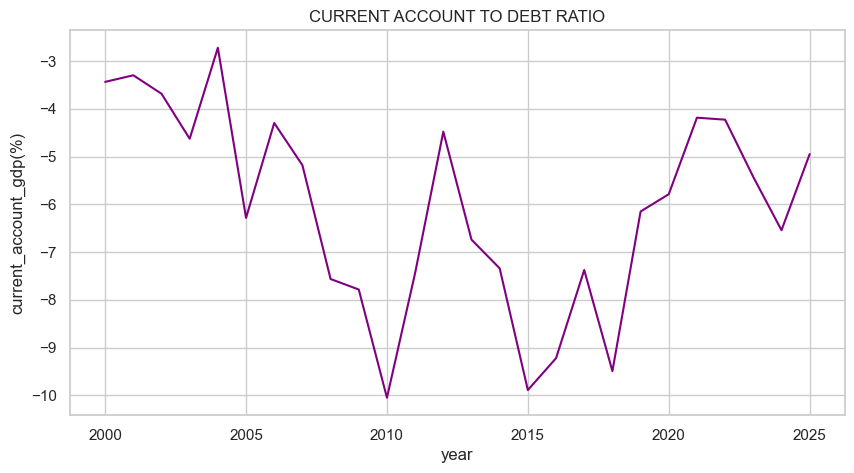

In [274]:
plt.figure(figsize=(10,5))
sns.lineplot(data = gambia_fiscal,
             x = "year",
             y = "current_account_gdp",
             errorbar=None,
             color = "purple")
plt.title("CURRENT ACCOUNT TO DEBT RATIO")
plt.savefig("current_account_to_dept_ratio", dpi = 300, bbox_inches = "tight")
plt.ylabel("current_account_gdp(%)")
plt.show()

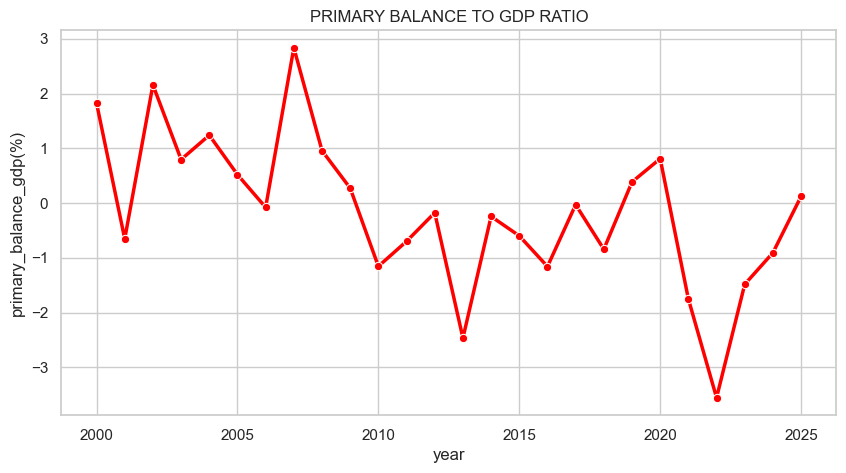

In [273]:
plt.figure(figsize=(10,5))
sns.lineplot(data = gambia_fiscal,
             x = "year",
             y = "primary_balance_gdp",
             marker = "o",
             linewidth = 2.5,
             errorbar=None,
            color ="red")
plt.title("PRIMARY BALANCE TO GDP RATIO")
plt.savefig("primary_balance_to_debt_ratio", dpi = 300, bbox_inches = "tight")
plt.ylabel("primary_balance_gdp(%)")
plt.show()

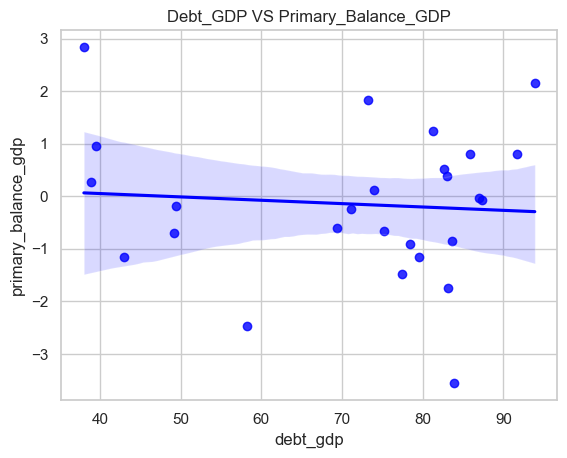

In [272]:
sns.regplot(data = gambia_fiscal,
            x = "debt_gdp",
            y = "primary_balance_gdp",
           color = "blue")
plt.title("Debt_GDP VS Primary_Balance_GDP")
plt.savefig("debt_gdp_vs_primary_balance", dpi = 300, bbox_inches = "tight")
plt.show()

In [213]:
gambia_fiscal["debt_gdp_change"] = gambia_fiscal["debt_gdp"].diff()

In [214]:
gambia_fiscal[["debt_gdp_change","primary_balance_gdp"]].corr()

CONCEPT_CODE,debt_gdp_change,primary_balance_gdp
CONCEPT_CODE,,
debt_gdp_change,1.000000,-0.362071
primary_balance_gdp,-0.362071,1.000000


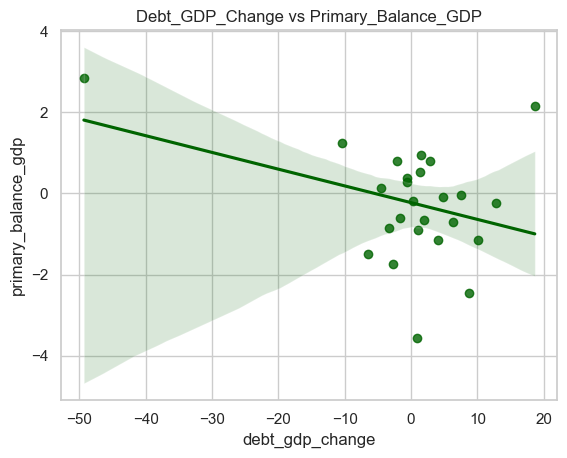

In [271]:
sns.regplot(data = gambia_fiscal,
            x = "debt_gdp_change",
            y = "primary_balance_gdp",
            color = "darkgreen")
plt.title("Debt_GDP_Change vs Primary_Balance_GDP")
plt.savefig("debt_gdp_change vs primary_balance_gdp", dpi = 300, bbox_inches = "tight")
plt.show()

CORRELATION ANALYSIS

In [216]:
gambia_fiscal[["debt_gdp_change","gdp_growth"]].corr()

CONCEPT_CODE,debt_gdp_change,gdp_growth
CONCEPT_CODE,,
debt_gdp_change,1.000000,-0.315223
gdp_growth,-0.315223,1.000000


In [217]:
gambia_fiscal[["debt_gdp_change","inflation"]].corr()

CONCEPT_CODE,debt_gdp_change,inflation
CONCEPT_CODE,,
debt_gdp_change,1.000000,-0.107917
inflation,-0.107917,1.000000


In [218]:
gambia_fiscal[["debt_gdp_change","current_account_gdp"]].corr()

CONCEPT_CODE,debt_gdp_change,current_account_gdp
CONCEPT_CODE,,
debt_gdp_change,1.000000,-0.178474
current_account_gdp,-0.178474,1.000000


# MERGE WB DATA ON GAMBIA FISCAL

In [225]:
wb["year"] = wb["year"].astype(int)

In [226]:
gambia_fiscal = pd.merge(gambia_fiscal,
                         wb,
                         on = "year",
                         how = "left")
gambia_fiscal

,year,current_account_gdp,revenue_gdp,fiscal_balance_gdp,primary_balance_gdp,total_debt,debt_gdp,expenditure_gdp,gdp_growth,inflation,debt_gdp_change,Exchange_Rate_GMD_per_USD
0,2000,-3.434987,9.447169,-0.090777,1.824460,9.457098,73.250229,9.537946,5.524896,0.850872,NaN,12.787625
1,2001,-3.296738,7.158574,-2.522861,-0.654820,11.830455,75.229867,9.681435,5.753038,4.492237,1.979638,15.687158
2,2002,-3.683212,8.653991,0.059383,2.157048,16.582880,93.875279,8.594608,-3.246948,8.609700,18.645412,19.917825
3,2003,-4.625704,7.569832,-1.732202,0.794467,22.050158,91.694292,9.302034,6.874318,17.031669,-2.180987,28.530508
4,2004,-2.720210,10.610562,-1.766022,1.238653,23.485166,81.303059,12.376584,7.045586,14.287287,-10.391233,30.030083
5,2005,-6.283065,9.614405,-3.332376,0.518411,24.256108,82.596471,12.946781,-2.351729,4.959359,1.293412,28.575433
6,2006,-4.296032,10.827504,-3.193722,-0.079113,25.840305,87.344267,14.021226,-0.555581,2.055788,4.747796,28.065725
7,2007,-5.179509,11.469229,0.274808,2.835338,12.102908,38.022861,11.194421,3.043249,5.369710,-49.321406,24.873433
8,2008,-7.562541,11.096676,-0.454399,0.956524,13.700216,39.528277,11.551075,6.255906,4.451085,1.505416,22.192350
9,2009,-7.782691,12.705557,-1.647544,0.271337,15.017920,38.868143,14.353101,6.665724,4.554231,-0.660134,26.644361


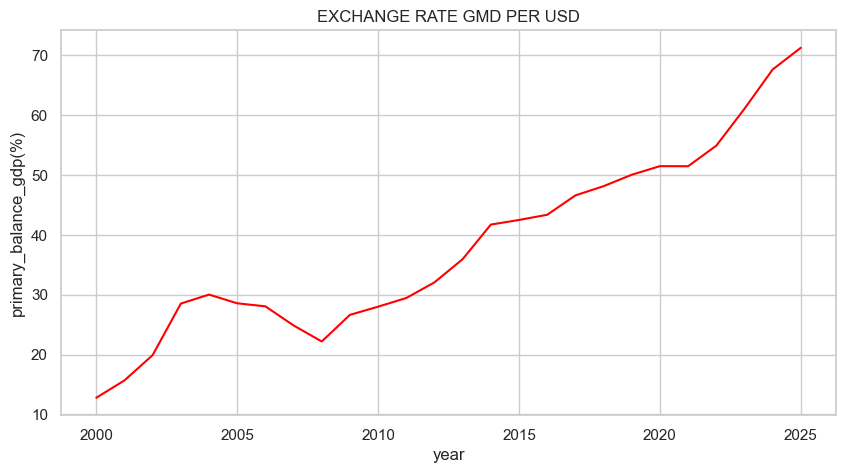

In [270]:
plt.figure(figsize=(10,5))
sns.lineplot(data = gambia_fiscal,
             x = "year",
             y = "Exchange_Rate_GMD_per_USD",
             color = "red",
             errorbar=None)
plt.title("EXCHANGE RATE GMD PER USD")
plt.ylabel("primary_balance_gdp(%)")
plt.savefig("exchange_rate_per_usd", dpi = 300, bbox_inches = "tight")
plt.show() 

In [232]:
gambia_fiscal = gambia_fiscal.rename(columns = {"EXCHANGE_RATE_GMD_PER_USD":"exchange_rate_gmd_per_usd"})

In [281]:
gambia_fiscal.to_csv("gambia_fiscal2.csv")

# CONCLUTION
This notebook provides a Python-based descriptive analysis of public debt dynamics in The Gambia between 2000 and 2025.

The analysis combines data preparation, exploratory analysis, and economic visualization to identify important patterns in debt, fiscal conditions, and macroeconomic performance.

The findings from this notebook provide the foundation for the subsequent time-series econometric analysis conducted in Stata.